In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("heart.csv")

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.shape

(303, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


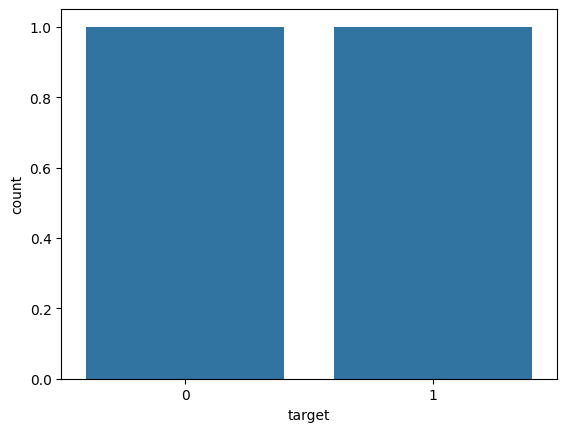

In [ ]:
sns.countplot(df['target'].value_counts())
plt.show()

In [ ]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [ ]:
# distance based algo -> Mapping and Eucleand
X = df.drop("target",axis=1)
y = df["target"]


EDA

### Data Distribution Analysis

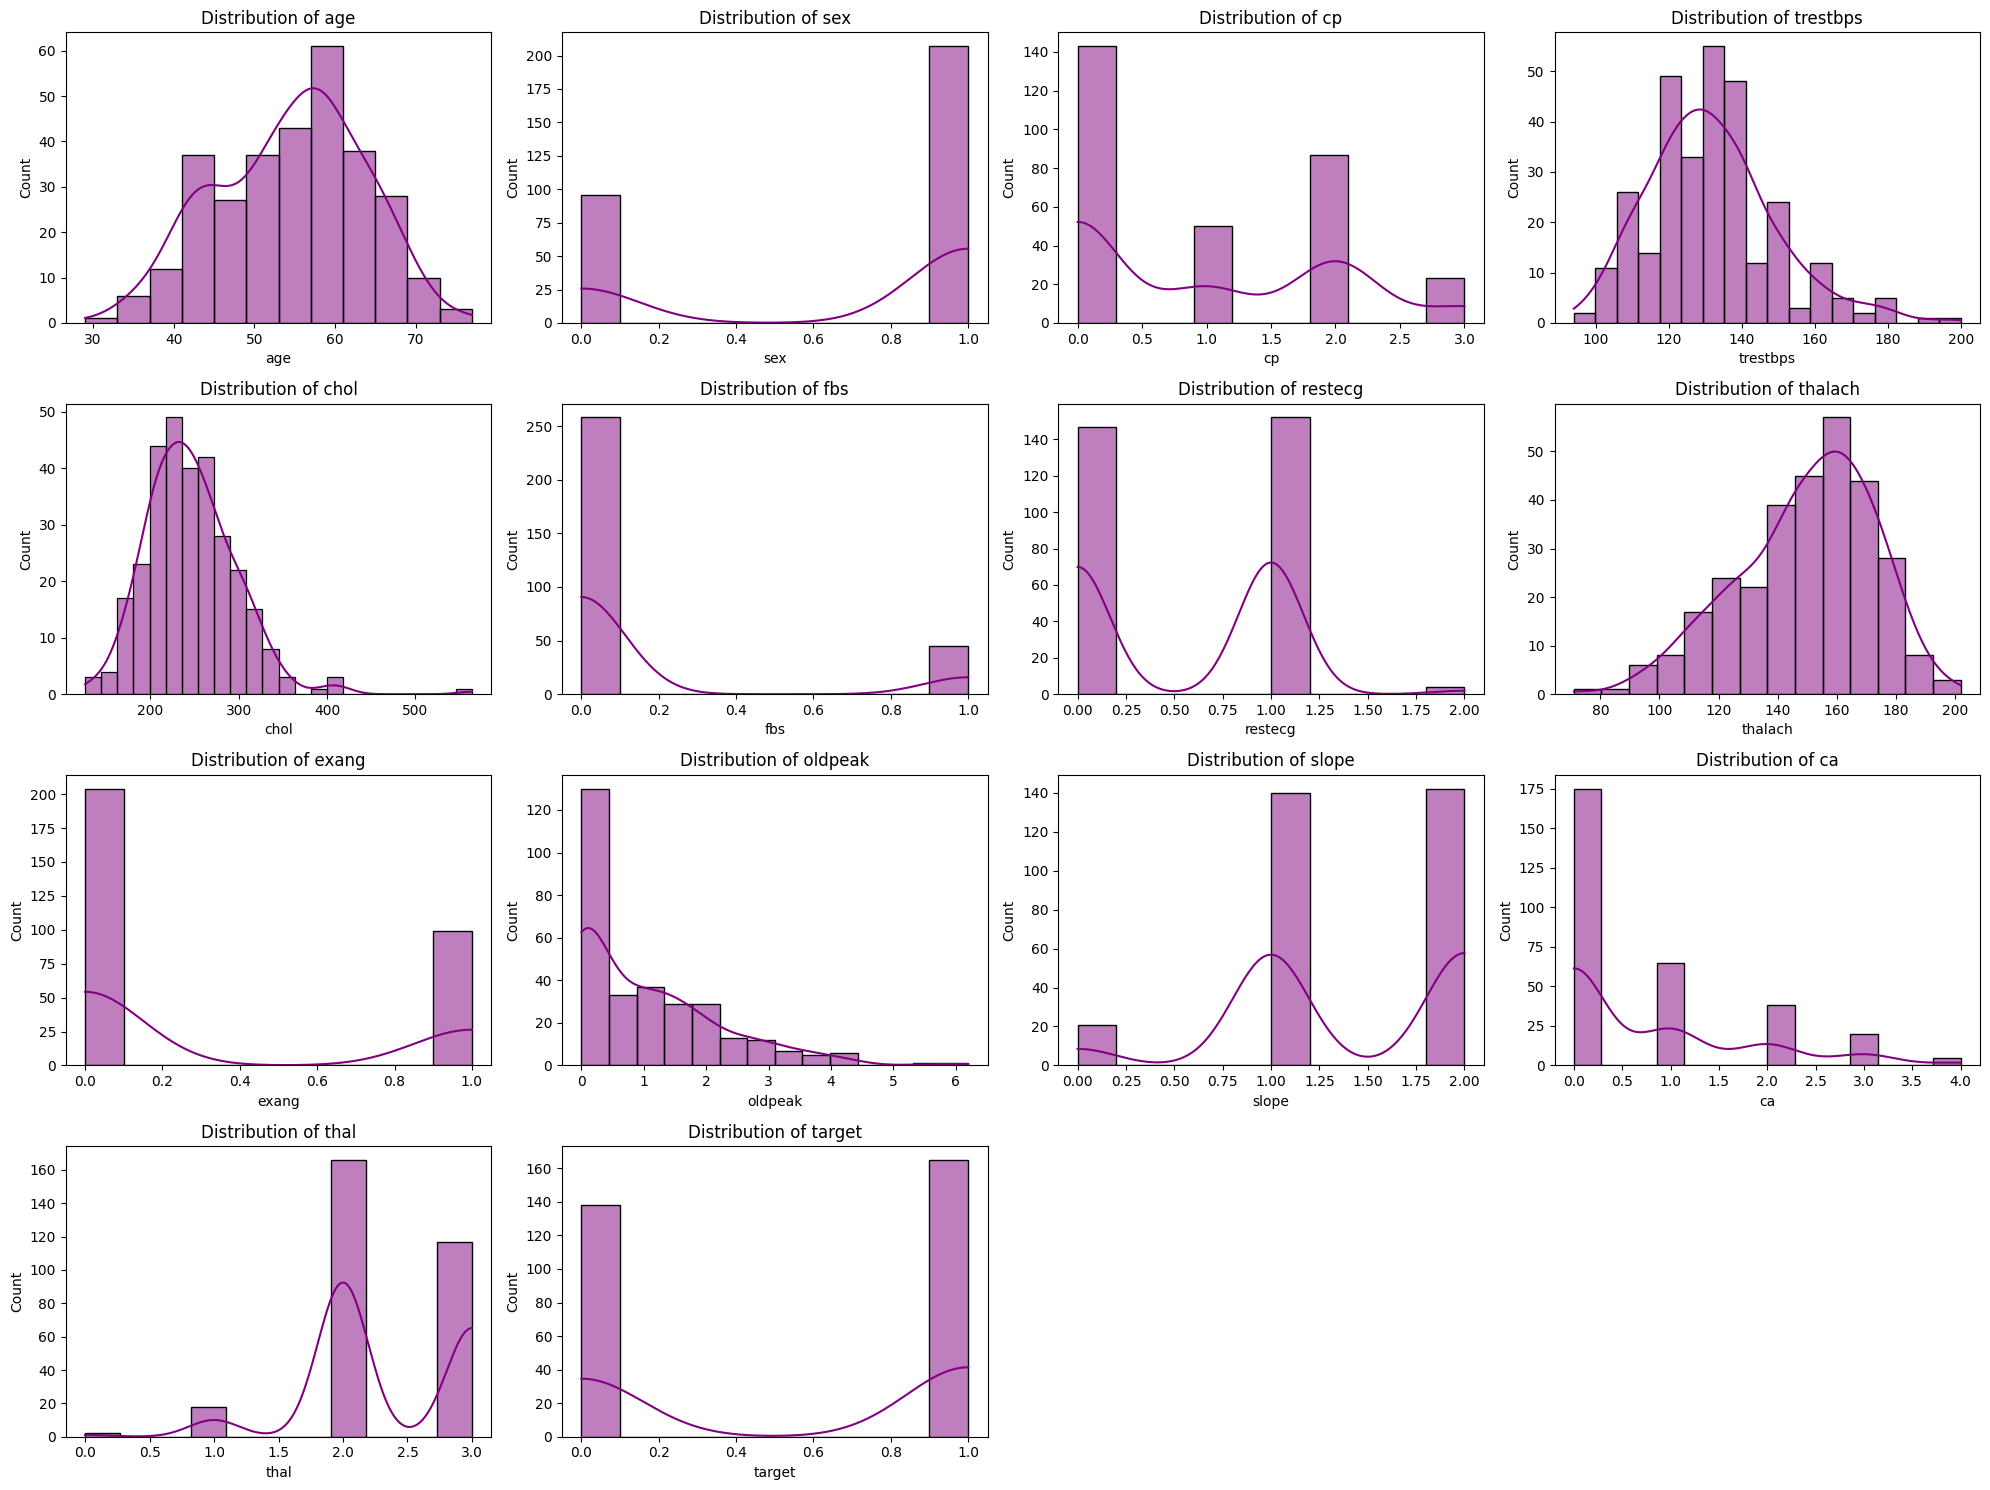

In [ ]:
# Plotting histograms for all numerical features to observe their distributions
fig = plt.figure(figsize=(20, 15))
for i, column in enumerate(df.columns):
    ax = fig.add_subplot(4, 4, i + 1)
    sns.histplot(df[column], kde=True, ax=ax ,color='purple')
    ax.set_title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

### Correlation Matrix

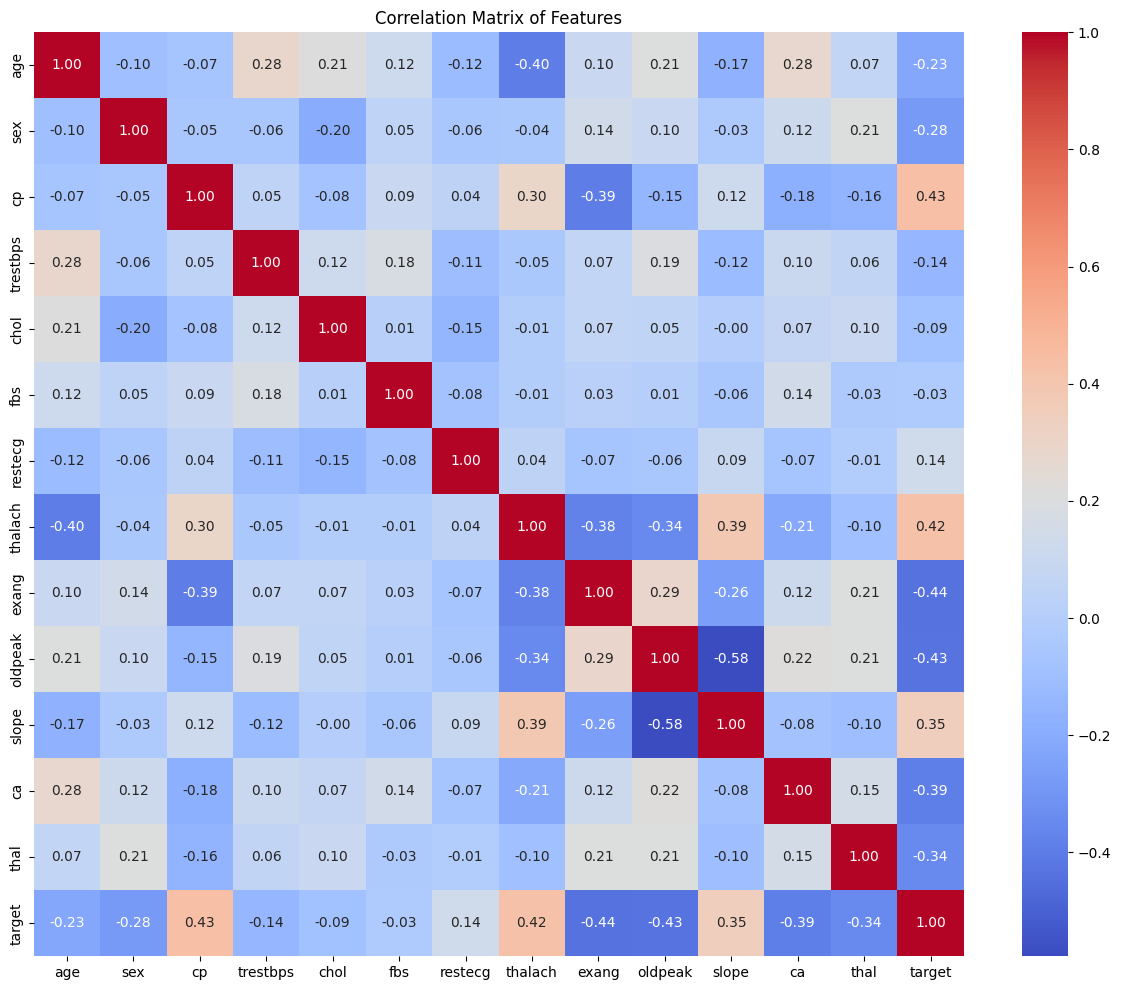

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Categorical Feature Analysis

/tmp/ipykernel_6842/4023516935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, ax=ax ,palette='rocket')
/tmp/ipykernel_6842/4023516935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, ax=ax ,palette='rocket')
/tmp/ipykernel_6842/4023516935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column, ax=ax ,palette='rocket')
/tmp/ipykernel_6842/4023516935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

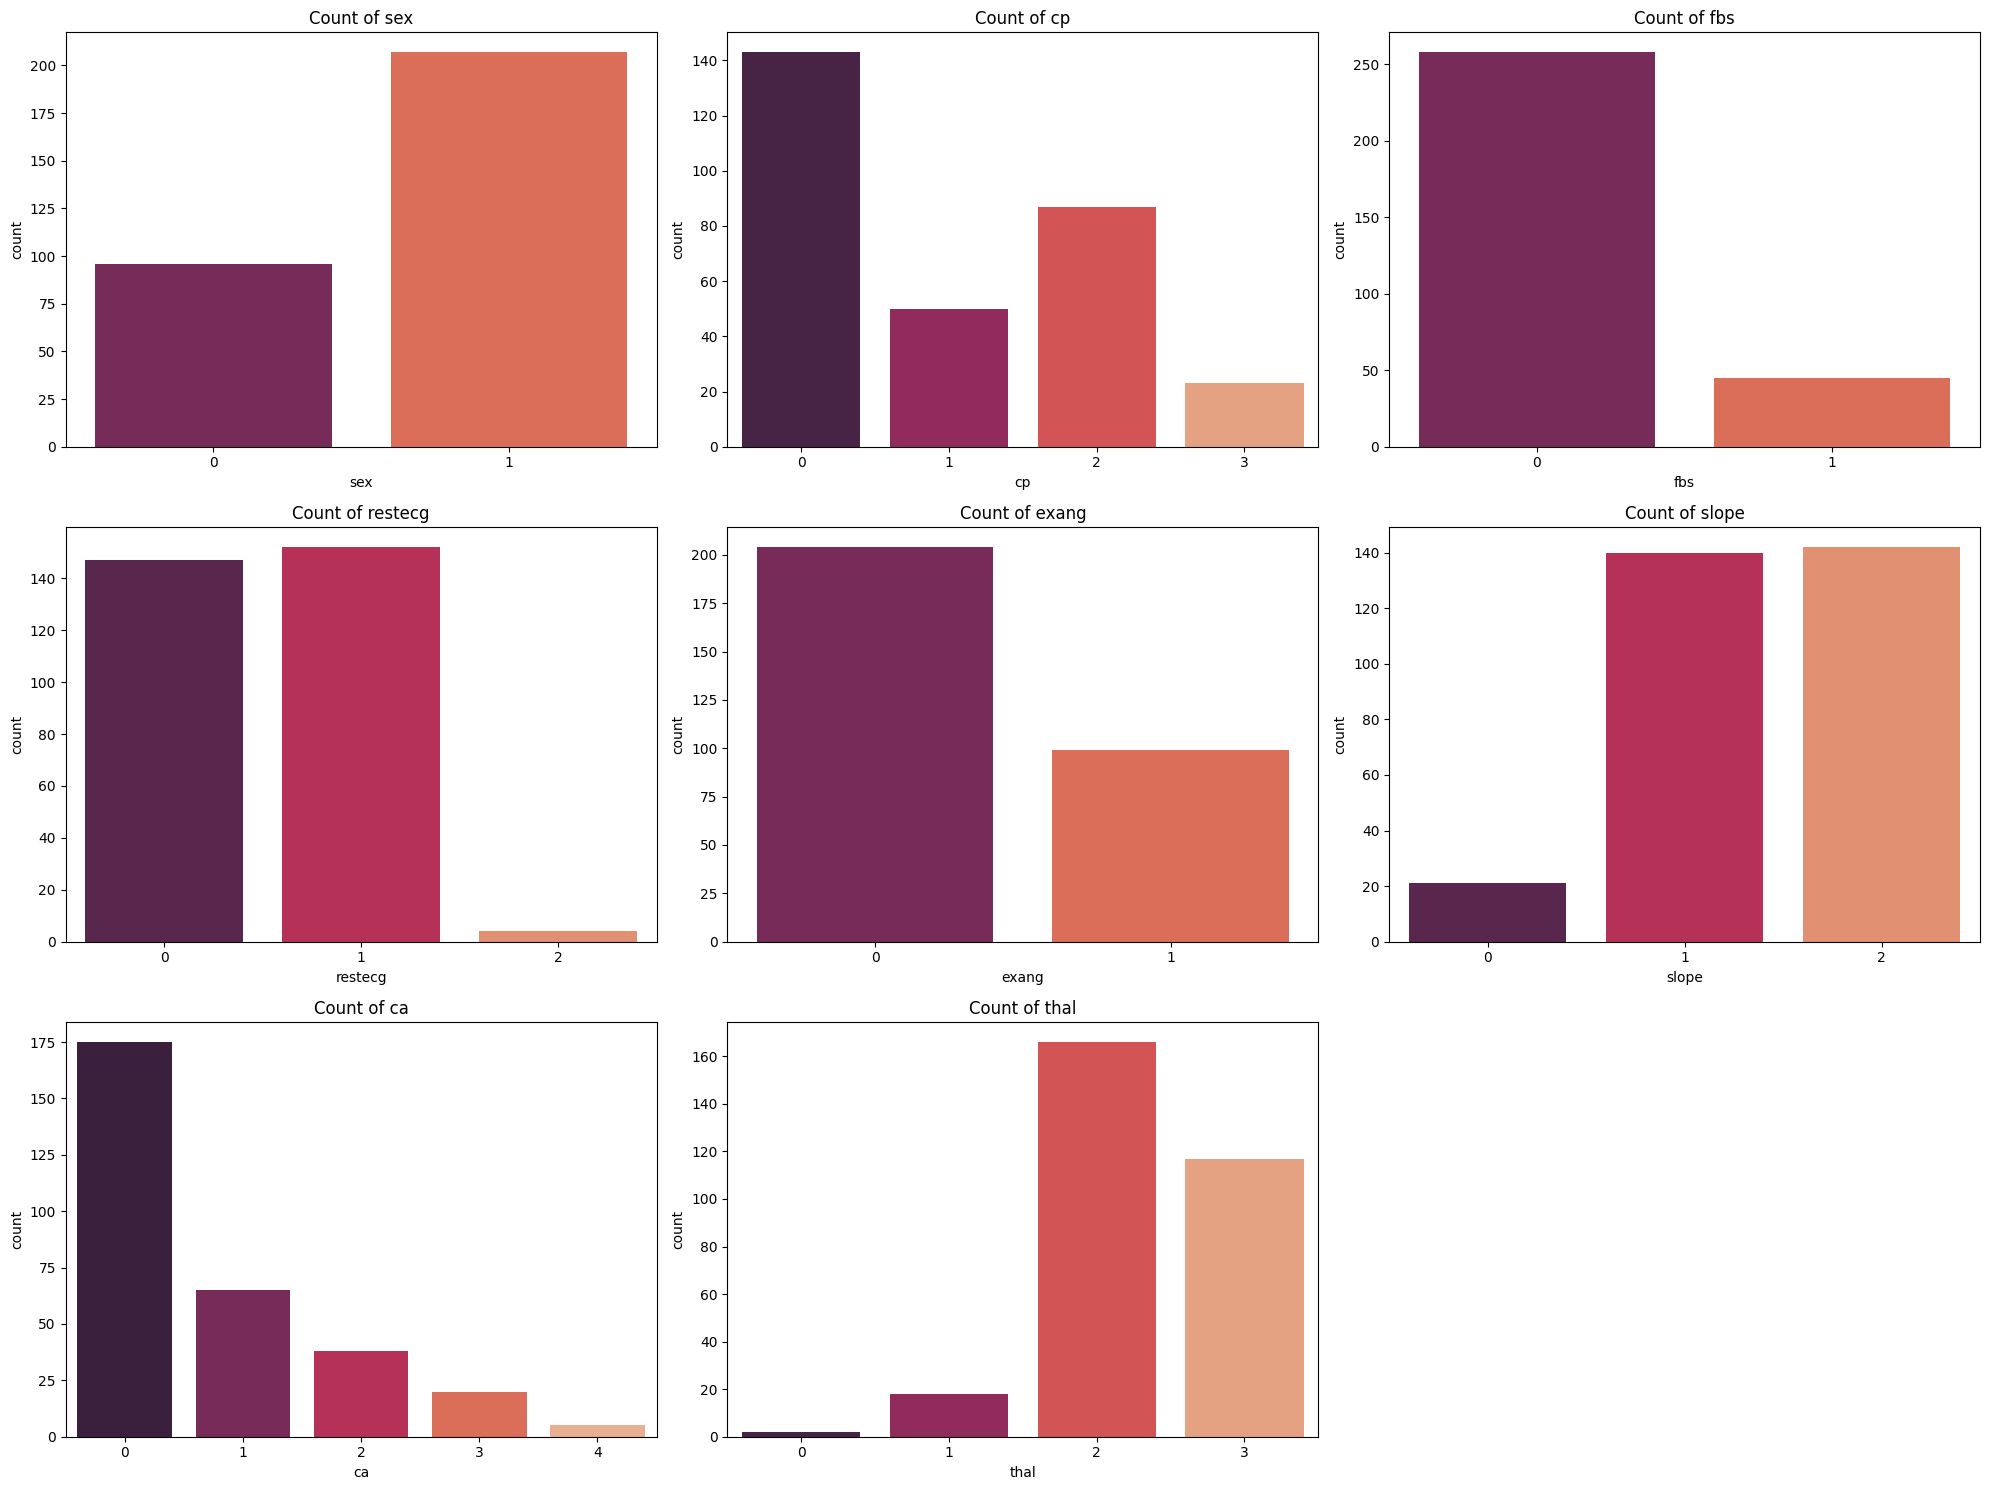

In [ ]:
# Identify categorical columns (excluding 'target' if it's considered numerical for now)
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Plotting count plots for all categorical features
fig = plt.figure(figsize=(20, 15))
for i, column in enumerate(categorical_cols):
    ax = fig.add_subplot(3, 3, i + 1)
    sns.countplot(data=df, x=column, ax=ax ,palette='rocket')
    ax.set_title(f'Count of {column}')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

model = DecisionTreeClassifier()


In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [ ]:
accuracy_score(y_test,y_pred)

0.819672131147541

In [ ]:
accuracy_score(y_train,model.predict(X_train))

1.0

<Axes: >

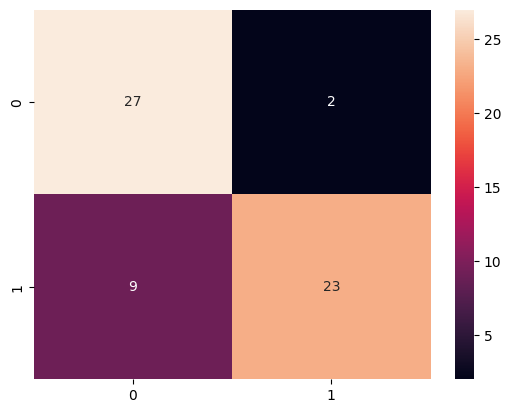

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)


In [ ]:
param_grid={
    'max_depth':[2,4,6,8,10],
    'criterion':['gini','entropy'],
    'min_samples_split':[2,4,6,8,10],
    'min_samples_leaf':[1,2,3,4,5]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

randomized_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    cv=5,
    n_iter=10,
    n_jobs=-1)

In [ ]:
randomized_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [2, 4, 6, 8, 10],
                                        'min_samples_leaf': [1, 2, 3, 4, 5],
                                        'min_samples_split': [2, 4, 6, 8, 10]})

In [ ]:
randomized_search.best_params_

{'min_samples_split': 8,
 'min_samples_leaf': 2,
 'max_depth': 4,
 'criterion': 'gini'}